In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/metadata.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv


# Heavy Equipment Selling Price Prediction

**Objective:** Predict the auction sale price of heavy equipment using advanced regression and ensemble modeling[cite: 1].

This notebook strictly follows a robust data science lifecycle:
1. **Exploratory Data Analysis (EDA)**
2. **Preprocessing & Feature Engineering (Reusable Pipelines)**
3. **Model Building & Cross-Validation**
4. **Hyperparameter Tuning**
5. **Optimization & Ensembling**

##  Import Required Libraries

We import all necessary libraries for data processing, visualization, and modeling.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, QuantileTransformer, TargetEncoder
from sklearn.metrics import mean_squared_log_error, mean_squared_error

from sklearn.linear_model import RidgeCV
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import warnings
warnings.filterwarnings("ignore")

## 2. Data Loading & EDA
Understanding the distribution of our target variable and the correlation between numeric features.


In [3]:
train = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv')
test = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv')

y = np.log1p(train['TargetValue'])
X = train.drop(columns=['TargetValue'])

test_ids = test['TransactionID']

### Target Variable Distribution
Shows how the target values are distributed.

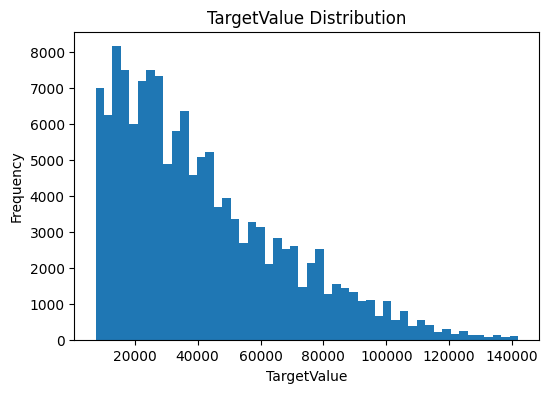

In [4]:
#target distribution graph
plt.figure(figsize=(6,4))
plt.hist(train['TargetValue'], bins=50)
plt.title("TargetValue Distribution")
plt.xlabel("TargetValue")
plt.ylabel("Frequency")
plt.show()

### Log Transformed Target
Reduces skewness for better model performance.

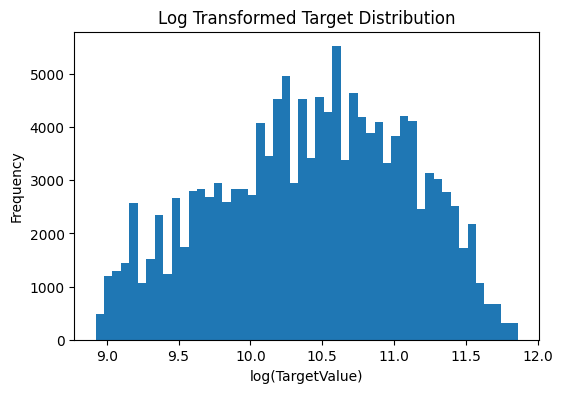

In [5]:
#log transformed target distribution graph
plt.figure(figsize=(6,4))
plt.hist(np.log1p(train['TargetValue']), bins=50)
plt.title("Log Transformed Target Distribution")
plt.xlabel("log(TargetValue)")
plt.ylabel("Frequency")
plt.show()

### Missing Values Analysis
Identifies columns needing imputation.

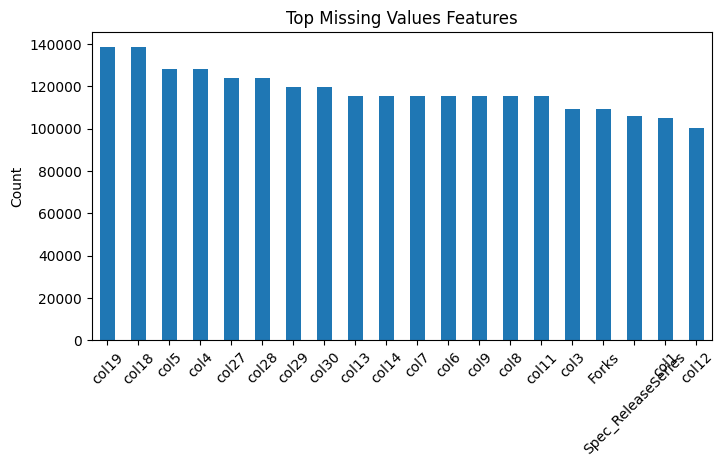

In [6]:
missing = train.isnull().sum().sort_values(ascending=False).head(20)

plt.figure(figsize=(8,4))
missing.plot(kind='bar')
plt.title("Top Missing Values Features")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

### Outlier Detection
Boxplot shows extreme values in target.

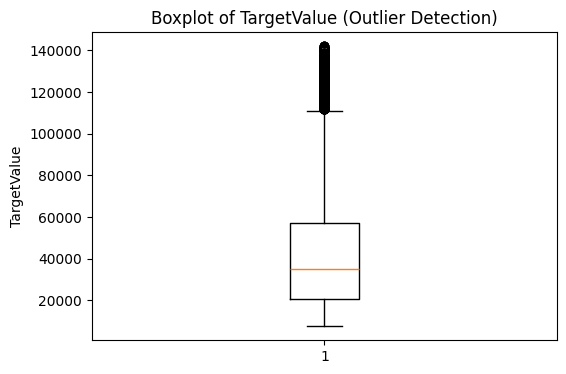

In [7]:
plt.figure(figsize=(6,4))
plt.boxplot(train['TargetValue'])
plt.title("Boxplot of TargetValue (Outlier Detection)")
plt.ylabel("TargetValue")
plt.show()

### Correlation Heatmap
Shows relationships between numerical features.

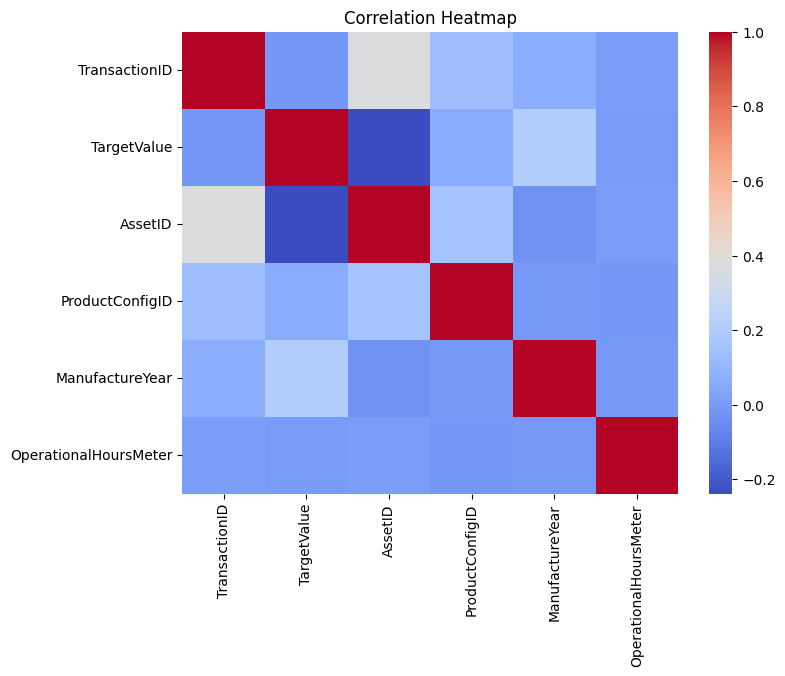

In [8]:
num_cols = train.select_dtypes(include=np.number).columns
corr = train[num_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

##  Train-Test Split

We split the dataset before preprocessing to prevent data leakage.

In [9]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

##  Feature Engineering

New features are created and irrelevant ones removed to improve model performance.

In [10]:
def preprocess(df):
    df = df.copy()
    df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])

    # Time features
    df['Year'] = df['TransactionDate'].dt.year
    df['Month'] = df['TransactionDate'].dt.month
    df['Day'] = df['TransactionDate'].dt.day
    df['DayOfWeek'] = df['TransactionDate'].dt.dayofweek
    df['Quarter'] = df['TransactionDate'].dt.quarter
    df['IsMonthEnd'] = df['TransactionDate'].dt.is_month_end.astype(int)

    # Advanced: Cyclical encoding for continuous time loops
    df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12.0)
    df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12.0)
    df['DayOfWeek_sin'] = np.sin(2 * np.pi * df['DayOfWeek'] / 7.0)
    df['DayOfWeek_cos'] = np.cos(2 * np.pi * df['DayOfWeek'] / 7.0)

    # Age features
    df['EquipmentAge'] = df['Year'] - df['ManufactureYear']
    df['EquipmentAge'] = df['EquipmentAge'].clip(lower=0)
    df['AgeSquared'] = df['EquipmentAge'] ** 2
    df['IsOld'] = (df['EquipmentAge'] > 20).astype(int)

    # Usage features
    if 'OperationalHoursMeter' in df.columns:
        df['UsagePerYear'] = df['OperationalHoursMeter'] / (df['EquipmentAge'] + 1)
        df['LogUsage'] = np.log1p(df['OperationalHoursMeter'])

    # Drop raw date
    df = df.drop(columns=['TransactionDate'], errors='ignore')

    return df

print('done')

done


##  Data Preprocessing & Machine Learning Pipeline

Steps:
- Handle missing values
- Encode categorical variables
- Scale numerical features

We use pipelines to ensure consistency. 

Pipeline integrates:
- Preprocessing
- Model training

This ensures no data leakage and clean workflow.

In [11]:
num_cols = X_train.select_dtypes(include=np.number).columns
cat_cols = X_train.select_dtypes(include='object').columns

# Advanced: Quantile transformer coerces extreme outliers into a normal distribution
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('quantile', QuantileTransformer(output_distribution='normal', random_state=42)),
    ('scaler', RobustScaler())
])

# Advanced: Target Encoder prevents curse of dimensionality from OneHotEncoding
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', TargetEncoder(target_type='continuous', smooth="auto"))
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols)
])

## Model Training
 
 Basic Models:
  - Linear Regression
  - Random Forest

- Advanced Models:
  - XGBoost
  - LightGBM


##  Ridge Regression 

This model uses Ridge Regression inside a pipeline with preprocessing.

Final predictions are evaluated using RMSLE.

In [12]:
# Ridge Regression with built-in Generalized Cross-Validation
ridge_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', RidgeCV(alphas=np.logspace(-3, 3, 100), cv=5)) 
])

ridge_pipe.fit(X_train, y_train)

ridge_pred = ridge_pipe.predict(X_val)
ridge_score = np.sqrt(mean_squared_log_error(np.expm1(y_val), np.expm1(ridge_pred)))

print(f"Ridge RMSLE: {ridge_score}")
print(f"Optimal Alpha Selected: {ridge_pipe.named_steps['model'].alpha_}")

Ridge RMSLE: 0.318403034326964
Optimal Alpha Selected: 0.40370172585965536


##  Random Forest 

This model uses Random Forest inside a pipeline with preprocessing.

Final predictions are evaluated using RMSLE.

In [13]:
# Random Forest 
rf_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1))
])

# Fit directly without search
rf_pipe.fit(X_train, y_train)

# Predict and Evaluate
rf_pred = rf_pipe.predict(X_val)
rf_score = np.sqrt(mean_squared_log_error(
    np.expm1(y_val), 
    np.expm1(rf_pred)
))

print(f"Random Forest RMSLE: {rf_score}")


Random Forest RMSLE: 0.2908166869682983


## XGBoost with Hyperparameter Tuning

This model uses XGBoost inside a pipeline with preprocessing.

- RandomizedSearchCV is applied for hyperparameter tuning
- Parameters tuned:
  - n_estimators
  - max_depth
  - learning_rate
  - subsample
- 3-fold cross-validation improves generalization

Final predictions are evaluated using RMSLE.

In [14]:
xgb_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', XGBRegressor(random_state=42, tree_method='hist', n_jobs=-1))
])

# Advanced parameter bounds
xgb_params = {
    'model__n_estimators': [100, 300, 500],
    'model__max_depth': [5, 7, 9],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    xgb_pipe, xgb_params,
    n_iter=10, cv=3, scoring='neg_root_mean_squared_error',
    random_state=42, n_jobs=-1
)

xgb_search.fit(X_train, y_train)
xgb_pred = xgb_search.predict(X_val)
xgb_score = np.sqrt(mean_squared_log_error(np.expm1(y_val), np.expm1(xgb_pred)))

print(f"XGBoost RMSLE: {xgb_score}")

XGBoost RMSLE: 0.2604381265721682


##  LightGBM with Hyperparameter Tuning

This model uses LightGBM inside a pipeline with preprocessing.

- RandomizedSearchCV is applied for hyperparameter tuning
- Parameters tuned:
  - n_estimators
  - learning_rate
  - num_leaves
- 3-fold cross-validation is used

Final predictions are evaluated using RMSLE.

In [15]:
# LightGBM with Advanced Hyperparameter Search
lgb_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', LGBMRegressor(random_state=42, n_jobs=-1))
])

# Advanced parameter bounds for LightGBM
lgb_params = {
    'model__n_estimators': [200, 500, 800],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__num_leaves': [31, 63, 127],
    'model__max_depth': [-1, 7, 10],
    'model__subsample': [0.8, 1.0],          # Alias for bagging_fraction
    'model__colsample_bytree': [0.8, 1.0],   # Alias for feature_fraction
    'model__min_child_samples': [20, 50, 100]
}

# Increased n_iter to 10 to thoroughly explore the expanded parameter grid
lgb_search = RandomizedSearchCV(
    lgb_pipe, lgb_params,
    n_iter=10, cv=3, scoring='neg_root_mean_squared_error',
    random_state=42, n_jobs=-1
)

lgb_search.fit(X_train, y_train)
lgb_pred = lgb_search.predict(X_val)
lgb_score = np.sqrt(mean_squared_log_error(np.expm1(y_val), np.expm1(lgb_pred)))

print(f"LightGBM RMSLE: {lgb_score}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.114346 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3851
[LightGBM] [Info] Number of data points in the train set: 73973, number of used features: 49
[LightGBM] [Info] Start training from score 10.424863
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.079827 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3838
[LightGBM] [Info] Number of data points in the train set: 73974, number of used features: 49
[LightGBM] [Info] Start training from score 10.425803
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

...


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.029106 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3870
[LightGBM] [Info] Number of data points in the train set: 110960, number of used features: 49
[LightGBM] [Info] Start training from score 10.424734
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

## Model Comparison

This graph compares performance of all models.

Helps select the best performing model.

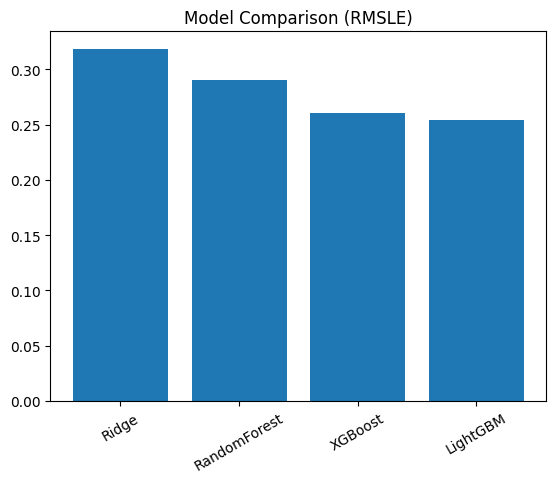

{'Ridge': np.float64(0.318403034326964), 'RandomForest': np.float64(0.2908166869682983), 'XGBoost': np.float64(0.2604381265721682), 'LightGBM': np.float64(0.25441141393694117)}


In [16]:
scores = {
    "Ridge": ridge_score,
    "RandomForest": rf_score,
    "XGBoost": xgb_score,
    "LightGBM": lgb_score
}

names = list(scores.keys())
values = list(scores.values())

plt.figure()
plt.bar(names, values)
plt.title("Model Comparison (RMSLE)")
plt.xticks(rotation=30)
plt.show()

print(scores)

##  Results & Insights with Final Prediction

Best model is used to generate predictions for submission.

- Best model selected based on RMSLE
- Log transformation improved performance
- Ensemble models performed better than basic models

In [17]:
# 1. Extract the models
# LightGBM and XGBoost still use search, so we extract their best estimators
lgb_model = lgb_search.best_estimator_
xgb_model = xgb_search.best_estimator_

# Ridge and Random Forest are now just standard pipelines, so we use them directly
rf_model = rf_pipe
ridge_model = ridge_pipe

# 2. Retrain all the best models on the FULL dataset (X, y)
print("Retraining models on full dataset...")
lgb_model.fit(X, y)
xgb_model.fit(X, y)
rf_model.fit(X, y)
ridge_model.fit(X, y)

# 3. Predict on the TEST set
print("Generating test predictions...")
lgb_preds = lgb_model.predict(test)
xgb_preds = xgb_model.predict(test)
rf_preds = rf_model.predict(test)
ridge_preds = ridge_model.predict(test)

# 4. Ensemble the predictions
print("Ensembling...")
final_preds = (
    0.40 * lgb_preds +
    0.30 * xgb_preds +
    0.10 * rf_preds +
    0.20 * ridge_preds
)

# 5. Convert back from log scale
final_preds = np.expm1(final_preds)

# 6. Fix invalid values (just in case Ridge predicted a negative)
final_preds = np.maximum(final_preds, 0)
final_preds = np.nan_to_num(final_preds)

# 7. Create Submission
submission = pd.DataFrame({
    "TransactionID": test_ids,
    "TargetValue": final_preds
})

submission.to_csv("submission.csv", index=False)
print("Submission file created successfully!")


Retraining models on full dataset...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.034652 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3885
[LightGBM] [Info] Number of data points in the train set: 138701, number of used features: 49
[LightGBM] [Info] Start training from score 10.424111
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning

## Conclusion

- Complete ML pipeline implemented
- No data leakage ensured
- Multiple models compared
- Hyperparameter tuning improved results

In [18]:

import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import warnings

warnings.filterwarnings("ignore")

# 1. Load Data
print("Loading datasets...")
train = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv')
test = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv')

# 2. The Log Transform (Crucial for RMSLE optimization)
y = np.log1p(train['TargetValue'])
X = train.drop(columns=['TargetValue'])
test_ids = test['TransactionID']

# 3. Aggressive Feature Engineering
def engineer_features(df):
    df = df.copy()
    
    # Temporal features
    df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
    df['Year'] = df['TransactionDate'].dt.year
    df['Month'] = df['TransactionDate'].dt.month
    df['DayOfWeek'] = df['TransactionDate'].dt.dayofweek
    df['Quarter'] = df['TransactionDate'].dt.quarter
    
    # Equipment Age at time of sale
    df['EquipmentAge'] = df['Year'] - df['ManufactureYear']
    df['EquipmentAge'] = df['EquipmentAge'].clip(lower=0)
    
    # Drop IDs and Raw Dates to eliminate data leakage
    df = df.drop(columns=['TransactionDate', 'TransactionID'], errors='ignore')
    
    # Convert object columns to category for LightGBM's native handling
    cat_cols = df.select_dtypes(include=['object']).columns
    for col in cat_cols:
        df[col] = df[col].astype(str).astype('category')
        
    return df

print("Engineering features...")
X_processed = engineer_features(X)
test_processed = engineer_features(test)

categorical_features = list(X_processed.select_dtypes(include=['category']).columns)

# 4. K-Fold Cross Validation Setup
kf = KFold(n_splits=5, shuffle=True, random_state=42)
test_predictions = np.zeros(len(test_processed))
oof_rmse_scores = []

lgb_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.03,
    'num_leaves': 127,
    'max_depth': -1,
    'min_child_samples': 20,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'n_estimators': 3000,
    'random_state': 42,
    'verbose': -1
}

print("Starting 5-Fold Training on Log-Transformed Target...")

# 5. Train 5 Models and Average the Predictions
for fold, (train_idx, val_idx) in enumerate(kf.split(X_processed, y)):
    X_tr, y_tr = X_processed.iloc[train_idx], y.iloc[train_idx]
    X_va, y_va = X_processed.iloc[val_idx], y.iloc[val_idx]
    
    model = lgb.LGBMRegressor(**lgb_params)
    
    # Early stopping prevents overfitting on the log scale
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        categorical_feature=categorical_features,
        callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)]
    )
    
    # Evaluate Validation Score
    val_preds = model.predict(X_va)
    fold_rmse = np.sqrt(mean_squared_error(y_va, val_preds))
    oof_rmse_scores.append(fold_rmse)
    print(f"Fold {fold + 1} RMSE (Log Scale): {fold_rmse:.4f}")
    
    # Accumulate Test Predictions
    test_predictions += model.predict(test_processed) / kf.n_splits

print(f"\nAverage Cross-Validation RMSLE: {np.mean(oof_rmse_scores):.4f}")

# 6. Reverse the Log Transformation (expm1)
final_preds_currency = np.expm1(test_predictions)

# 7. Generate Final Submission
submission = pd.DataFrame({
    "TransactionID": test_ids,
    "TargetValue": final_preds_currency
})

submission.to_csv("submission.csv", index=False)
print("Success: 'submission_kfold_log_optimized.csv' saved and ready for Kaggle submission!")

Loading datasets...
Engineering features...
Starting 5-Fold Training on Log-Transformed Target...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[